<a href="https://colab.research.google.com/github/crigouzzo/Non_minimal_Coupling_Gravity_Axion/blob/main/ACT_DR6_ps_likelihood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interacting with the ACT DR6 Power Spectrum Likelihood

*Written by Serena Giardiello, Sam Goldstein, Hidde Jense and the ACT collaboration*

---
This notebook demonstrates useful applications of the ACT DR6 power spectrum and its likelihood. The ACT DR6 power spectrum and its covariance matrix are the key data products that form the ACT DR6 likelihood, and they are built from various inputs using [`PSpipe`](https://github.com/simonsobs/PSpipe). Building these products is too involved for a notebook, but the pipeline to do so is fully-reproducible within PSpipe, as described [here](https://github.com/simonsobs/PSpipe/tree/master/project/ACT_DR6).

Here, we'll use the pre-packaged [multi-frequency ACT DR6 likelihood](https://github.com/ACTCollaboration/act_dr6_mflike). In the ACT DR6 analysis we have also used the [foreground-marginalized, CMB-only ACT DR6 likelihood](https://github.com/ACTCollaboration/dr6-cmbonly). These two likelihoods are both built around [`cobaya`](https://github.com/CobayaSampler). The former includes all power spectra from individual detector arrays and frequency channels for which systematic parameters and frequency sensitivities differ. The latter marginalizes over all foreground and systematic parameters, except an overall calibration and polarization efficiency. The CMB-only likelihood is faster and simpler, and sufficient for tests of cosmology involving only the lensed primary CMB power spectrum.

We'll work with the data and methods for each of these likelihoods by demonstrating:
* Loading raw spectra and covariance matrices from a `sacc` file
* Plotting the ACT DR6 spectra, errors, and residuals to a cosmological theory
* Calling the ACT DR6 likelihood act_dr6_mflike and assessing the $\chi^2$ of a given cosmological model
* Show a standard yaml to run the ACT DR6 chains and to run a minimizer run
* Plotting cosmological constraints from an MCMC chain with `getdist`
* Installing and comparing the DR6 CMB-only likelihood ACT-lite to the multifrequency likelihood.
* Running a (short) chain with ACT-lite.

This notebook simplifies some analysis steps to make it as easy-to-use as possible (e.g., by using the default `Recfast` recombination code in `camb`. A full scientific analysis using the ACT DR6 power spectrum likelihood should follow the instructions at [ACT-DR6-parameters](https://github.com/ACTCollaboration/ACT-DR6-parameters) to properly configure the likelihood to run on a cluster.

## Load the necessary packages

In [1]:
!pip install -q camb sacc cobaya

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.0/495.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 834.1/834.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.1 MB/s eta 0:00:00


# Downloading data and code

In [2]:
# download the sacc file that contains all the DR6 spectra and covariance matrix
!wget https://lambda.gsfc.nasa.gov/data/act/pspipe/sacc_files/dr6_data.tar.gz
!tar -xvzf dr6_data.tar.gz

--2026-04-14 13:00:58--  https://lambda.gsfc.nasa.gov/data/act/pspipe/sacc_files/dr6_data.tar.gz
Resolving lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)... 129.164.179.68, 2001:4d0:2310:150::68
Connecting to lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)|129.164.179.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 413203437 (394M) [application/x-gzip]
Saving to: ‘dr6_data.tar.gz’

dr6_data.tar.gz     100%[===================>] 394.06M  8.65MB/s    in 46s     

2026-04-14 13:01:44 (8.51 MB/s) - ‘dr6_data.tar.gz’ saved [413203437/413203437]

v1.0/
v1.0/dr6_data.fits


## Loading spectra and covariances from a `sacc`

First of all, let's install the likelihood used for ACT DR6 analysis. We first clone it from GitHub and then install all the data and codes needed.

In [3]:
!pip install -q act_dr6_mflike


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 414.3/414.3 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.3/250.3 kB 13.3 MB/s eta 0:00:00


## Plotting spectra and theory residuals

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

import camb
import cobaya

We first define our likelihoods settings. We use both the ACT DR6 likelihood and the Planck 2018 low-ell EE SRoll2, used to constrain $\tau$:

In [5]:
act_dr6_config = {'act_dr6_mflike.ACTDR6MFLike':
                  # input file settings
                {'data_folder': 'ACTDR6MFLike/v1.0',
                'input_file': "dr6_data.fits",
                 # setting the array names, the analyzed spectra and the ell cuts for each of them
                 "requested_cls": ["tt", "te", "ee"],
                'defaults': {'symmetrize': False,
                              'polarizations': ['TT', 'TE', 'ET', 'EE'],
                              'polarizations_auto': ['TT', 'TE', 'EE'],
                              'lmax': 8500,
                              'scales': {'TT': [2, 8500], 'TE': [2, 8500], 'ET': [2, 8500], 'EE': [2, 8500]}},
                'data': {'experiments':
                          ['dr6_pa4_f220', 'dr6_pa5_f090', 'dr6_pa5_f150', 'dr6_pa6_f090', 'dr6_pa6_f150'],
                'spectra': [{'experiments': ['dr6_pa4_f220', 'dr6_pa4_f220'],
                            'polarizations': ['TT'], 'scales': {'TT': [1000, 8500]}},
                          {'experiments': ['dr6_pa4_f220', 'dr6_pa5_f090'], 'polarizations': ['TT'],
                            'scales': {'TT': [1000, 8500]}},
                          {'experiments': ['dr6_pa4_f220', 'dr6_pa5_f150'], 'polarizations': ['TT'],
                            'scales': {'TT': [1000, 8500]}},
                          {'experiments': ['dr6_pa4_f220', 'dr6_pa6_f090'], 'polarizations': ['TT'],
                            'scales': {'TT': [1000, 8500]}},
                          {'experiments': ['dr6_pa4_f220', 'dr6_pa6_f150'], 'polarizations': ['TT'],
                            'scales': {'TT': [1000, 8500]}},
                          {'experiments': ['dr6_pa5_f090', 'dr6_pa5_f090'], 'polarizations': ['TT', 'TE', 'EE'],
                            'scales': {'TT': [1000, 8500], 'TE': [1000, 8500], 'EE': [1000, 8500]}},
                          {'experiments': ['dr6_pa5_f090', 'dr6_pa5_f150'],
                            'scales': {'TT': [1000, 8500], 'TE': [1000, 8500],
                                      'ET': [1000, 8500], 'EE': [1000, 8500]}},
                          {'experiments': ['dr6_pa5_f090', 'dr6_pa6_f090'],
                            'scales': {'TT': [1000, 8500], 'TE': [1000, 8500],
                                      'ET': [1000, 8500], 'EE': [1000, 8500]}},
                          {'experiments': ['dr6_pa5_f090', 'dr6_pa6_f150'],
                            'scales': {'TT': [1000, 8500], 'TE': [1000, 8500], 'ET': [1000, 8500],
                                      'EE': [1000, 8500]}},
                          {'experiments': ['dr6_pa5_f150', 'dr6_pa5_f150'], 'polarizations': ['TT', 'TE', 'EE'],
                            'scales': {'TT': [800, 8500], 'TE': [800, 8500], 'EE': [800, 8500]}},
                          {'experiments': ['dr6_pa5_f150', 'dr6_pa6_f090'],
                            'scales': {'TT': [1000, 8500], 'TE': [1000, 8500],
                                      'ET': [1000, 8500], 'EE': [1000, 8500]}},
                          {'experiments': ['dr6_pa5_f150', 'dr6_pa6_f150'],
                            'scales': {'TT': [800, 8500], 'TE': [800, 8500], 'ET': [800, 8500], 'EE': [800, 8500]}},
                          {'experiments': ['dr6_pa6_f090', 'dr6_pa6_f090'], 'polarizations': ['TT', 'TE', 'EE'],
                            'scales': {'TT': [1000, 8500], 'TE': [1000, 8500], 'EE': [1000, 8500]}},
                          {'experiments': ['dr6_pa6_f090', 'dr6_pa6_f150'],
                            'scales': {'TT': [1000, 8500], 'TE': [1000, 8500],
                                      'ET': [1000, 8500], 'EE': [1000, 8500]}},
                          {'experiments': ['dr6_pa6_f150', 'dr6_pa6_f150'], 'polarizations': ['TT', 'TE', 'EE'],
                            'scales': {'TT': [600, 8500], 'TE': [600, 8500], 'EE': [600, 8500]}}]},

                 },
                  # SRoll2 likelihood used to constrain tau
                  "planck_2018_lowl.EE_sroll2": {}
                  }


Let's first learn how to read the power spectra and covariance matrices from our input data file. We need ``sacc`` for this purpose:

In [6]:
import sacc
s = sacc.Sacc.load_fits("v1.0/dr6_data.fits")

Assuming data rows are in the correct order as it was before version 1.0.


In [54]:
# list of the data types used of the spectra, and the corresponding labels to use in the plots below
dtl = {"cl_00": "TT", "cl_0e": "TE", "cl_0b": "TB", "cl_ee": "EE", "cl_eb": "EB", "cl_be": "BE", "cl_bb":"BB"}

def find_scale_cuts(t1, t2, field):
     for i in act_dr6_config["act_dr6_mflike.ACTDR6MFLike"]["data"]["spectra"]:
        if i["experiments"] == [t1, t2]:
            ell_min = i["scales"]["TT"][0]
            ell_max = i["scales"]["TT"][1]
            return ell_min, ell_max

def plot_dl_cov(data_type):
    field = dtl[data_type]
    plt.figure()
    for dt in s.get_data_types():
        if dt == data_type:
            for t1,t2 in s.get_tracer_combinations(dt):
                ell,cl,cov,ind = s.get_ell_cl(dt,t1,t2, return_cov =True,return_ind = True)
                lmin, lmax = find_scale_cuts(t1[:-3], t2[:-3], field)
                elln = [l for l in ell if l >= lmin and l <= lmax]
                iell = np.isin(ell, elln)
                covd = cov[np.ix_(iell, iell)]
                cl_err = np.sqrt(np.diag(covd))
                dl=cl[iell]*elln*(elln+1)/ (2.0 * np.pi)
                dl_err= cl_err[iell]*elln*(elln+1)/ (2.0 * np.pi)
                plt.errorbar(elln, dl[iell], dl_err, fmt = '.',  label = f"{t1[:-3]}x{t2[:-3]}")
                if field == "TT":
                    plt.yscale("log")
            plt.legend(loc = (1.1,0.1))
            plt.xlabel(r"$\ell$")
            plt.ylabel(r"$D^{"+f"{field}"+r"}_{\ell}$")
            figure = plt.figure()
            axes = figure.add_subplot(111)
            mat = axes.matshow(np.corrcoef(cov))
            figure.colorbar(mat)
            axes.set_title(f"{field} correlation matrix")

In [71]:
def plot_dl_cov(data_type):
    field = dtl[data_type]
    plt.figure()

    for dt in s.get_data_types():
        if dt == data_type:
            for t1, t2 in s.get_tracer_combinations(dt):
                ell, cl, cov, ind = s.get_ell_cl(
                    dt, t1, t2, return_cov=True, return_ind=True
                )

                lmin, lmax = find_scale_cuts(t1[:-3], t2[:-3], field)

                iell = (ell >= lmin) & (ell <= lmax) & (ell <= 3500)
                elln = ell[iell]

                covd = cov[np.ix_(iell, iell)]
                cl_err = np.sqrt(np.diag(covd))

                dl = cl[iell] * elln * (elln + 1) / (2.0 * np.pi)
                dl_err = cl_err * elln * (elln + 1) / (2.0 * np.pi)

                plt.errorbar(
                    elln,
                    dl,
                    dl_err,
                    fmt='.',
                    label=f"{t1[:-3]}x{t2[:-3]}"
                )

                if field == "TT":
                    plt.yscale("log")

    plt.legend(loc=(1.1, 0.1))
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$D^{" + f"{field}" + r"}_{\ell}$")

In [75]:
def plot_dl_cov_2(data_type):
    field = dtl[data_type]
    plt.figure()

    t1, t2 = s.get_tracer_combinations(data_type)[9]

    ell, cl, cov, ind = s.get_ell_cl(
        data_type, t1, t2, return_cov=True, return_ind=True
    )

    lmin, lmax = find_scale_cuts(t1[:-3], t2[:-3], field)

    iell = (ell >= lmin) & (ell <= lmax) & (ell <= 3500)
    elln = ell[iell]

    covd = cov[np.ix_(iell, iell)]
    cl_err = np.sqrt(np.diag(covd))

    dl = cl[iell] * elln * (elln + 1) / (2.0 * np.pi)
    dl_err = cl_err * elln * (elln + 1) / (2.0 * np.pi)

    plt.errorbar(
        elln,
        dl,
        dl_err,
        fmt='.',
        label=f"{t1[:-3]}x{t2[:-3]}"
    )

    if field == "TT":
        plt.yscale("log")

    plt.legend(loc=(1.1, 0.1))
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$D^{" + f"{field}" + r"}_{\ell}$")

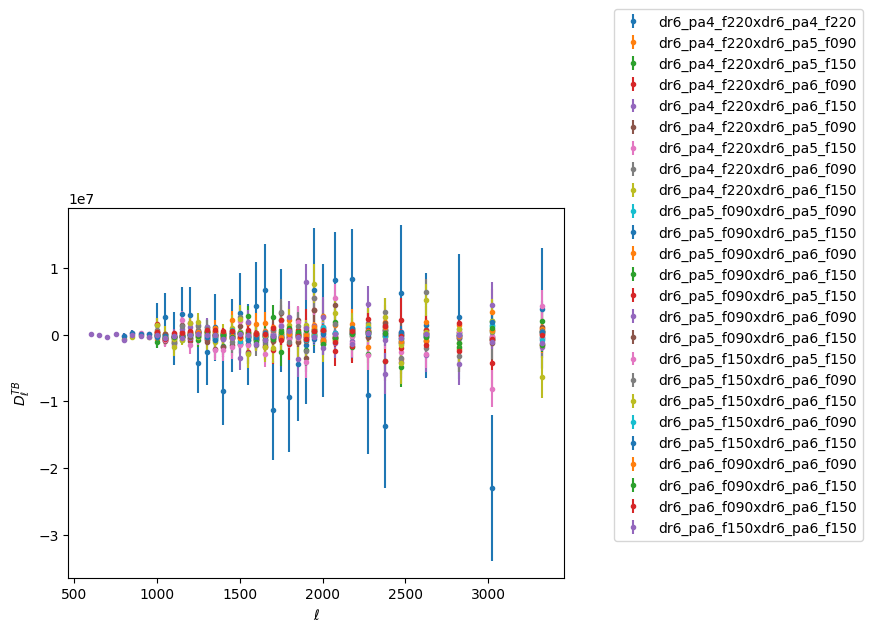

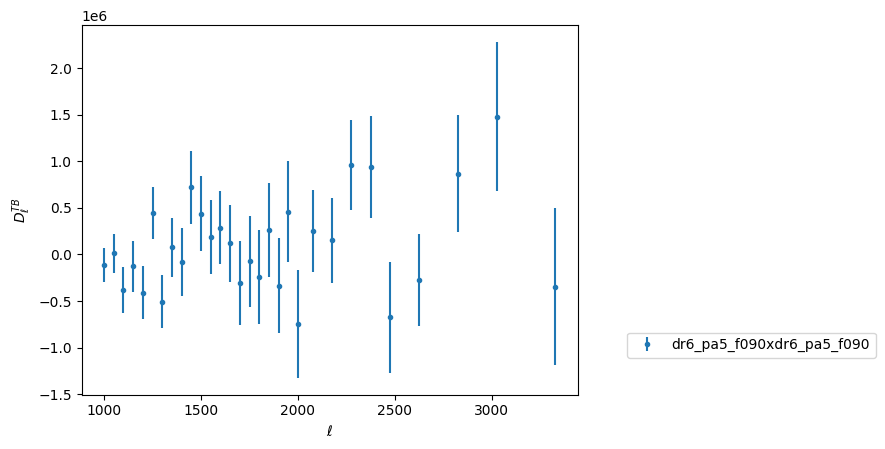

In [76]:
plot_dl_cov("cl_0b")
plot_dl_cov_2("cl_0b")

From the data ``sacc`` file we can also extract other data products, for example the passbands and the (frequency dependent) beams used in the analysis

In [ ]:
bands = {}
beams = {}
for name, tracer in s.tracers.items():
    bands[name] = {"nu": tracer.nu, "bandpass": tracer.bandpass}
    beams[name] = {"nu": tracer.nu, "beams": tracer.beam.T }

Text(0.5, 0, '$\\nu$ [GHz]')

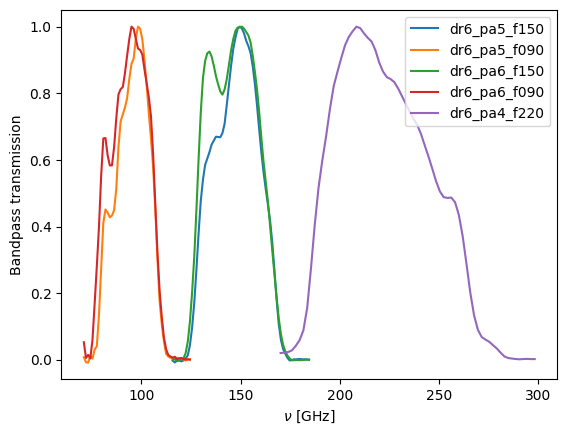

In [ ]:
for k in bands.keys():
    if k[-2:] == "s0":
        plt.plot(bands[k]["nu"], bands[k]["bandpass"]/max(bands[k]["bandpass"]), label = k[:-3])
plt.legend()
plt.ylabel("Bandpass transmission")
plt.xlabel(r"$\nu$ [GHz]")

we can plot the beams for each array for a single frequency

Text(0, 0.5, '$b_{\\ell}$')

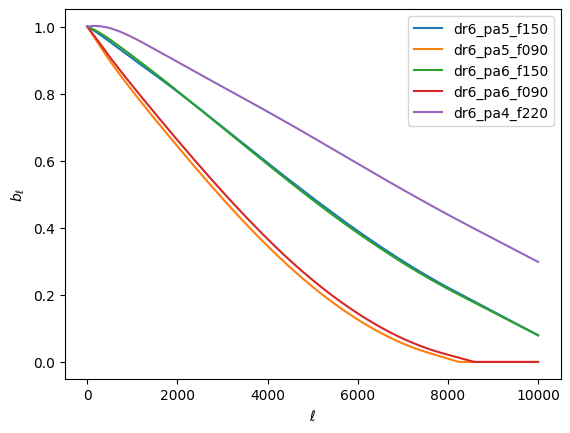

In [ ]:
ells = np.arange(10000)
for k in beams.keys():
    if k[-2:] == "s0":
        plt.plot(ells, beams[k]["beams"][0], label= k[:-3])
plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r"$b_{\ell}$")

To plot the theory $\Lambda$CDM CMB and foreground power spectra given the ACT DR6 bestfit parameters, we first have to initialize the ACT DR6 likelihood and evaluate it for this set of parameters.

We set the input parameters (cosmological, astrophysical foregrounds and nuisance parameters) to the best-fit ACT DR6 $\Lambda$CDM values

In [ ]:
# ACT DR6 best fit lcdm params

cosmo_params = {
    "ombh2": 0.02261650205,
    "omch2": 0.1240404189,
    "cosmomc_theta": 0.01040547237,
    "ns": 0.9663813976,
    "tau": 0.05655092745,
    "Alens": 1.0,
    "As": 2.127445742e-09,
}


fg_params = {
    "a_tSZ": 3.50114277,              #tSZ amplitude
    "alpha_tSZ": -0.4597721879,       #tSZ ell slope
    "a_kSZ": 0.986604682,             #kSZ amplitude
    "a_p": 7.647742104,               #CIB Poisson amplitude
    "beta_p": 1.86490755,             #CIB Poisson spectral index
    "a_c": 3.805341822,               #CIB clustered amplitude
    "beta_c": 1.86490755,             #CIB Poisson spectral index, fixed to be the same as beta_s
    "a_s": 2.886594272,               #radio sources TT amplitude
    "beta_s": -2.7567784,             #radio spectral index
    "a_gtt": 7.974213801,             #galactic dust TT amplitude
    "a_gte": 0.4184588365,            #galactic dust TE amplitude
    "a_gee": 0.1676466062,            #galactic dust EE amplitude
    "a_psee": 0.003755819497,         #radio sources TE amplitude
    "a_pste": -0.02500092711,         #radio sources EE amplitude
    "xi": 0.06424293336,              #amplitude of tSZxCIB cross correlation
    "T_d": 9.60,                      #dust temperature
    "alpha_s": 1,                     #radio ell slope
    "T_effd": 19.6,                   #effective galactic dust temperature
    "beta_d": 1.5,                    #galactic dust spectral index
    "alpha_dT": -0.6,                 #galactic dust ell slope for T
    "alpha_dE": -0.4,                 #galactic dust ell slope for E
    "alpha_p": 1,                     #CIB Poisson ell slope
}

nuisance_params = {
    "calG_all": 1.001567048,                            #overall calibration to Planck
    "cal_dr6_pa4_f220": 0.9808084654,                   #calibrations
    "cal_dr6_pa5_f090": 1.000098497,
    "cal_dr6_pa5_f150": 0.9991342522,
    "cal_dr6_pa6_f090": 0.9998031382,
    "cal_dr6_pa6_f150": 1.001407626,
    "calE_dr6_pa5_f090": 0.9874026803,                  #polarization efficiencies
    "calE_dr6_pa5_f150": 0.9975776488,
    "calE_dr6_pa6_f090": 0.9975750142,
    "calE_dr6_pa6_f150": 0.9968551529,
    "bandint_shift_dr6_pa4_f220": 6.399328024,          #bandpass shifts
    "bandint_shift_dr6_pa5_f090": -0.2911716302,
    "bandint_shift_dr6_pa5_f150": -1.056426408,
    "bandint_shift_dr6_pa6_f090": 0.3121747872,
    "bandint_shift_dr6_pa6_f150": -0.4252785128,
    "calE_dr6_pa4_f220": 1.0,                           #PA4 220 is not used in polarization, so its pol. efficiency is fixed to 1
    }

We also need to set the accuracy settings for the recombination code used, in this case CAMB. Notice that in our runs with CAMB we have used the CosmoRec recombination code, which is more accurate than the CAMB default one (RECFAST). Since it is difficult to install it here, let's just use the CAMB default for the purpose of this notebook.

In [ ]:
high_accuracy_settings = dict(
    kmax=10,
    k_per_logint=130,
    nonlinear=True,
    lens_potential_accuracy=8,
    lens_margin=2050,
    lAccuracyBoost=1.2,
    min_l_logl_sampling=6000,
    DoLateRadTruncation=False,
    halofit_version = "mead2020",
   # recombination_model=CosmoRec
)

We set now all the blocks needed from Cobaya. The total dictionary has this structure:

```
info = {   "params": params block,                  # all the input params  
           "likelihood": likelihood block,          # all the likelihoods used (act_dr6_mflike and planck_2018_lowl.EE_sroll2)
           "theory": theory block,                  # all the theory classes (camb for the CMB power spectra and mflike.BandpowerForeground for the foreground power spectra)
           "prior": priors block,                   # all the priors needed
           "packages_path": link to the installation folder
           "data_folder": name of the data folder under "packages_path/data"
}
```



In [ ]:
info = {
    "params": cosmo_params | fg_params | nuisance_params,

    "likelihood": act_dr6_config,

    "theory": {"camb": {"extra_args": high_accuracy_settings},
               # Class for the foreground power spectra computation
               "mflike.BandpowerForeground":
               # This line includes the effect of chromatic beams. Not to include it, change it to "beam_profile": {}
               {"beam_profile": {"beam_from_file": {}},
               # This line tells the likelihood to perform bandpass integration with the ACT DR6 bandpasses saved in our data file
               # If you want to use a top-hat bandpass, fill the dictionary "top_hat_band": {"nsteps": [...], "bandwidth": [...]}
                "top_hat_band": {},
               # Setting the foreground normalization and components
                'normalisation': {'nu_0': 150.0,
                                 'ell_0': 3000,
                                  'T_CMB': 2.725},
                 'components': {'tt': ['kSZ', 'tSZ_and_CIB', 'cibp', 'dust', 'radio'],
                                'te': ['radio', 'dust'],
                                'ee': ['radio', 'dust']},
               # Setting the array names and nominal frequencies for the BandpowerForeground class
                "experiments": ["dr6_pa4_f220","dr6_pa5_f090", "dr6_pa5_f150", "dr6_pa6_f090", "dr6_pa6_f150"],
                "bandint_freqs": [220, 90, 150, 90, 150]
                                  }},

    "prior": { "TTdust_prior": "lambda a_gtt: stats.norm.logpdf(a_gtt, loc=7.95, scale=0.32)",
               "TEdust_prior": "lambda a_gte: stats.norm.logpdf(a_gte, loc=0.423, scale=0.03)",
               "EEdust_prior": "lambda a_gee: stats.norm.logpdf(a_gee, loc=0.1681, scale=0.017)",
               'calG_all_prior': 'lambda calG_all: stats.norm.logpdf(calG_all, loc=1.0, scale=0.003)',
               'cal_dr6_pa4_f220_prior': 'lambda cal_dr6_pa4_f220: stats.norm.logpdf(cal_dr6_pa4_f220, loc=1.0, scale=0.013)',
               'cal_dr6_pa5_f090_prior': 'lambda cal_dr6_pa5_f090: stats.norm.logpdf(cal_dr6_pa5_f090, loc=1.0, scale=0.0016)',
               'cal_dr6_pa5_f150_prior': 'lambda cal_dr6_pa5_f150: stats.norm.logpdf(cal_dr6_pa5_f150, loc=1.0, scale=0.0020)',
               'cal_dr6_pa6_f090_prior': 'lambda cal_dr6_pa6_f090: stats.norm.logpdf(cal_dr6_pa6_f090, loc=1.0, scale=0.0018)',
               'cal_dr6_pa6_f150_prior': 'lambda cal_dr6_pa6_f150: stats.norm.logpdf(cal_dr6_pa6_f150, loc=1.0, scale=0.0024)',
               'bandint_shift_dr6_pa4_f220_prior': 'lambda bandint_shift_dr6_pa4_f220: stats.norm.logpdf(bandint_shift_dr6_pa4_f220, loc=0.0, scale=3.6)',
               'bandint_shift_dr6_pa5_f090_prior': 'lambda bandint_shift_dr6_pa5_f090: stats.norm.logpdf(bandint_shift_dr6_pa5_f090, loc=0.0, scale=1.0)',
               'bandint_shift_dr6_pa5_f150_prior': 'lambda bandint_shift_dr6_pa5_f150: stats.norm.logpdf(bandint_shift_dr6_pa5_f150, loc=0.0, scale=1.3)',
               'bandint_shift_dr6_pa6_f090_prior': 'lambda bandint_shift_dr6_pa6_f090: stats.norm.logpdf(bandint_shift_dr6_pa6_f090, loc=0.0, scale=1.2)',
               'bandint_shift_dr6_pa6_f150_prior': 'lambda bandint_shift_dr6_pa6_f150: stats.norm.logpdf(bandint_shift_dr6_pa6_f150, loc=0.0, scale=1.1)'},

    "packages_path": "./packages",

    "data_folder": "ACTDR6MFLike/v1.0",
}

We install the likelihoods needed

In [ ]:
from cobaya.install import install

packages_path = "./packages"
install(info, path=packages_path, no_set_global=True, skip_global=True, debug= True);

INFO:install:Installing external packages at '/content/packages'


 2025-03-20 17:40:07,041 [install] Installing external packages at '/content/packages'


INFO:install:Checking if dependencies have already been installed...



theory:camb

 2025-03-20 17:40:07,049 [install] Checking if dependencies have already been installed...


DEBUG:CAMB:Attempting global import (`path='global'` given).


...

 2025-03-20 17:40:07,181 [install] External dependencies for this component already installed.


INFO:install:Doing nothing.


 2025-03-20 17:40:07,186 [install] Doing nothing.


INFO:install:All requested components' dependencies correctly installed at /content/packages



* Summary * 

 2025-03-20 17:40:07,187 [install] All requested components' dependencies correctly installed at /content/packages


Now we evaluate the likelihood

In [ ]:
from cobaya.model import get_model

model = get_model(info)

act_dr6_like = model.likelihood["act_dr6_mflike.ACTDR6MFLike"]

 2025-03-20 17:40:07,659 [model] *WARNING* Ignored blocks/options: ['data_folder']


 2025-03-20 17:40:07,709 [prior] *WARNING* External prior 'TTdust_prior' loaded. Mind that it might not be normalized!


 2025-03-20 17:40:07,715 [prior] *WARNING* External prior 'TEdust_prior' loaded. Mind that it might not be normalized!


 2025-03-20 17:40:07,718 [prior] *WARNING* External prior 'EEdust_prior' loaded. Mind that it might not be normalized!


 2025-03-20 17:40:07,720 [prior] *WARNING* External prior 'calG_all_prior' loaded. Mind that it might not be normalized!


...

 2025-03-20 17:40:07,798 [camb] `camb` module loaded successfully from /usr/local/lib/python3.11/dist-packages/camb


INFO:act_dr6_mflike.actdr6mflike:Number of bins used: 1651


 2025-03-20 17:40:33,207 [act_dr6_mflike.actdr6mflike] Number of bins used: 1651


INFO:act_dr6_mflike.actdr6mflike:Initialized!


 2025-03-20 17:40:33,214 [act_dr6_mflike.actdr6mflike] Initialized!


Let us first plot the theory CMB + foreground power spectra given our bestfit parameters

First we ask CAMB to compute the theory CMB power spectrum

In [ ]:
# this is to make sure all the likelihood components have been properly initialized
model.logposterior({})
dls = model.theory["camb"].get_Cl(ell_factor=True)

then we compute the total foreground power spectra (summed over all the foreground components) and the total CMB + foreground ones

In [ ]:
# building a dictionary of the theory CMB spectra selecting the $\ell$ range we need
ell = act_dr6_like.l_bpws
dls_cmb = {mode: dls[mode][ell] for mode in ["tt", "te", "ee", "bb"]}

In [ ]:
# initializing the foreground class and computing the total FG power spectra
foreground_model = model.theory["mflike.BandpowerForeground"]
fg_totals = foreground_model.get_fg_totals()
# computing the total theory CMB + FG power spectra given our nuisance parameters
dl_obs = act_dr6_like.get_modified_theory(dls_cmb, fg_totals, **nuisance_params)

Finally, we fill a dictionary with the foreground power spectra separated by component and frequency.

This is useful for plotting reasons

In [ ]:
fg_models = foreground_model.get_foreground_model(ell=ell, **fg_params)

Let's plot the CMB and foreground power spectra for the different frequencies

In [ ]:
import matplotlib.pyplot as plt


def plot_simulation(*cross):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for mode, ax in zip(["tt", "ee", "te", "et"], axes.flatten()):
        if cross[0] == cross[1] and mode == "et":
            fig.delaxes(ax)
            continue

        ax.legend([], title="{} - {}x{}".format(mode.upper(), *cross))
        if mode == "tt":
            ax.set(yscale="log", ylim=(0.1, 10_000))

        mode = "te" if mode == "et" else mode

        ax.plot(ell, dls_cmb[mode], "-r", label="theory")
        ax.plot(ell, fg_models[mode, "all", cross[0], cross[1]], "-b", label="all foregrounds")
        ax.plot(ell, dl_obs[mode, cross[0], cross[1]], "--g", lw=2, label="theory + FG with instrument parameters",)
        ax.set_xlabel(r"$\ell$")

    fig.supylabel(r"$D_\ell$")
    fig.legend(*axes[0, 0].get_legend_handles_labels(), bbox_to_anchor=(1.3, 1));

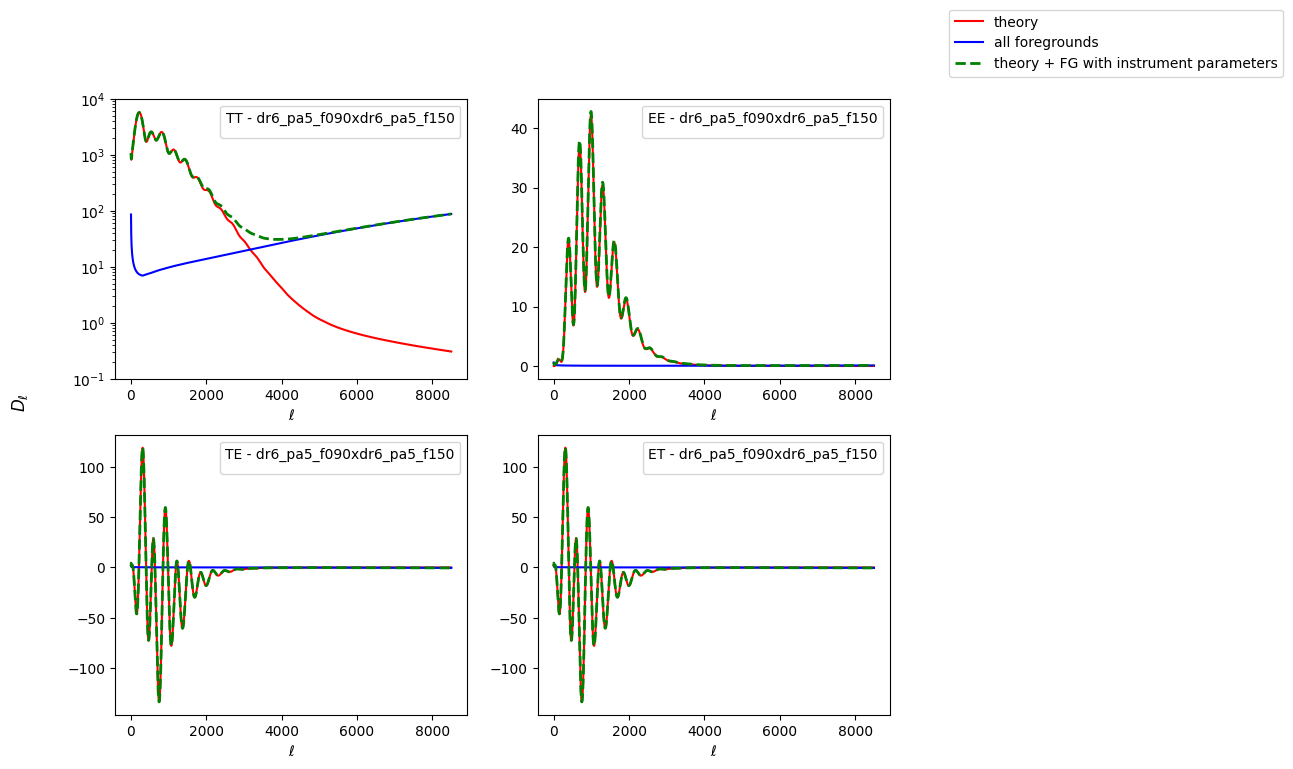

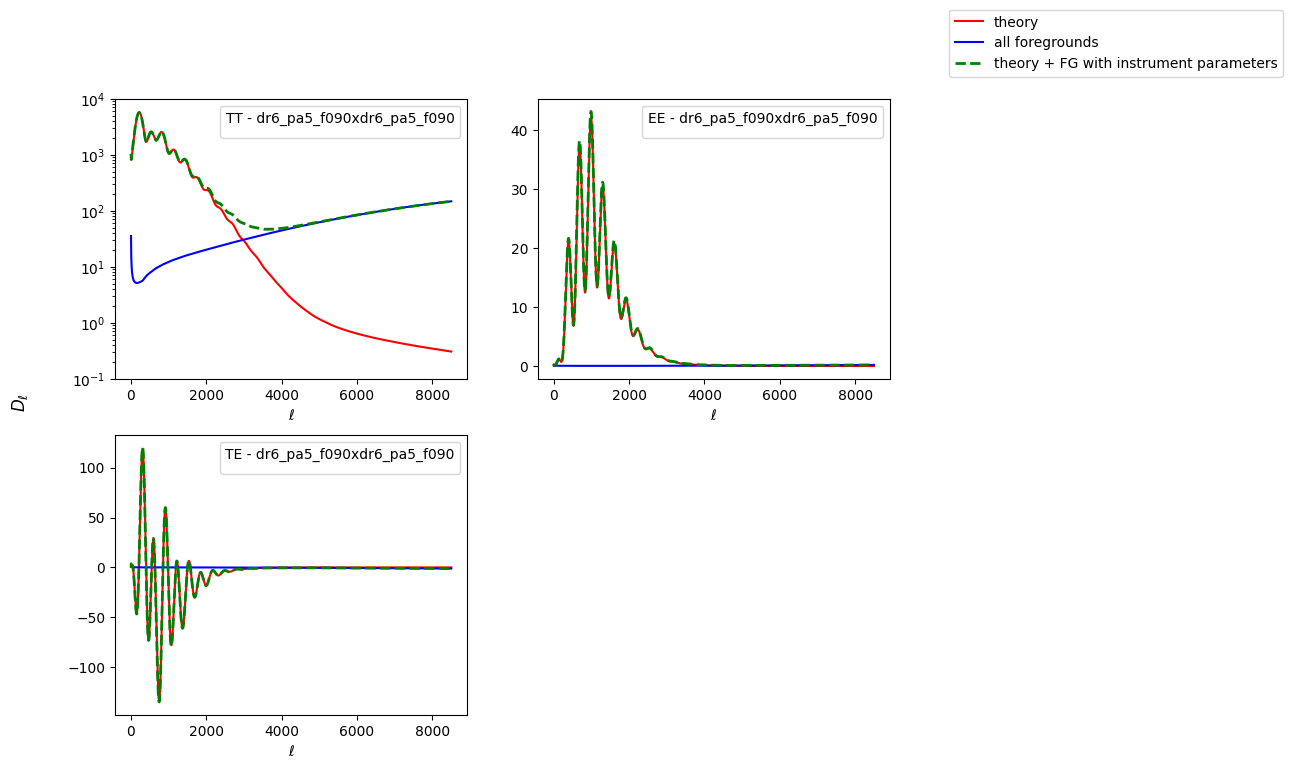

In [ ]:
plot_simulation("dr6_pa5_f090", "dr6_pa5_f150")
plot_simulation("dr6_pa5_f090", "dr6_pa5_f090")

We can also plot the different foreground components separately in the different array combinations

In [ ]:
from itertools import product

experiments = act_dr6_like.experiments
nexperiments = len(experiments)

# for plotting reason, we separate tSZ, CIB clustered and their cross-correlation
import copy
components = copy.deepcopy(foreground_model.components)
components["tt"].remove("tSZ_and_CIB")
for i in ["tSZ", "cibc", "tSZxCIB"]:
    components["tt"].append(i)

def plot_fg_spectra(mode):
    fig, axes = plt.subplots(nexperiments, nexperiments, sharex=True, sharey=True, figsize=(15, 15))
    for i, cross in enumerate(product(experiments, experiments)):
        idx = (i % nexperiments, i // nexperiments)
        ax = axes[idx]
        if idx in zip(*np.triu_indices(nexperiments, k=1)):
            fig.delaxes(ax)
            continue
        ax.plot(ell, fg_models[mode, "all", cross[0], cross[1]], color="k")
        for compo in components[mode]:
            if not (fg_models[mode, compo, cross[0], cross[1]] < 0).any():
                ax.plot(ell, fg_models[mode, compo, cross[0], cross[1]])
            else:
                ax.plot(ell, np.abs(fg_models[mode, compo, cross[0], cross[1]]), ls="--")
        if not (dls_cmb[mode] < 0).any():
            ax.plot(ell, dls_cmb[mode], color="tab:gray")
        else:
            ax.plot(ell, np.abs(dls_cmb[mode]), color="tab:gray", ls="--")
        title = f"{cross[0]}x{cross[1]}"
        ax.legend([], title=title, fontsize = 13)
        ax.set_yscale("log")
        if mode == "tt":
            ax.set_ylim(10**-2, 10**4)

    comp_name = copy.deepcopy(components)
    comp_name["tt"] = ["|tSZxCIB+CIBxtSZ|" if n == "tSZxCIB" else n for n in comp_name["tt"]]
    for i in range(nexperiments):
        axes[-1, i].set_xlabel("$\ell$", fontsize = 13)
        axes[i, 0].set_ylabel("$D_\ell$", fontsize = 13)
    fig.legend(
        ["all"] + comp_name[mode],
        title=mode.upper(),
        labelcolor="linecolor",
        handlelength=0,
        bbox_to_anchor=(0.6, 1),
        fontsize = 13
    )
    plt.tight_layout()

Here the CMB is plotted in gray and all the foreground components with different colors. Negative spectra are plotted as dashed lines

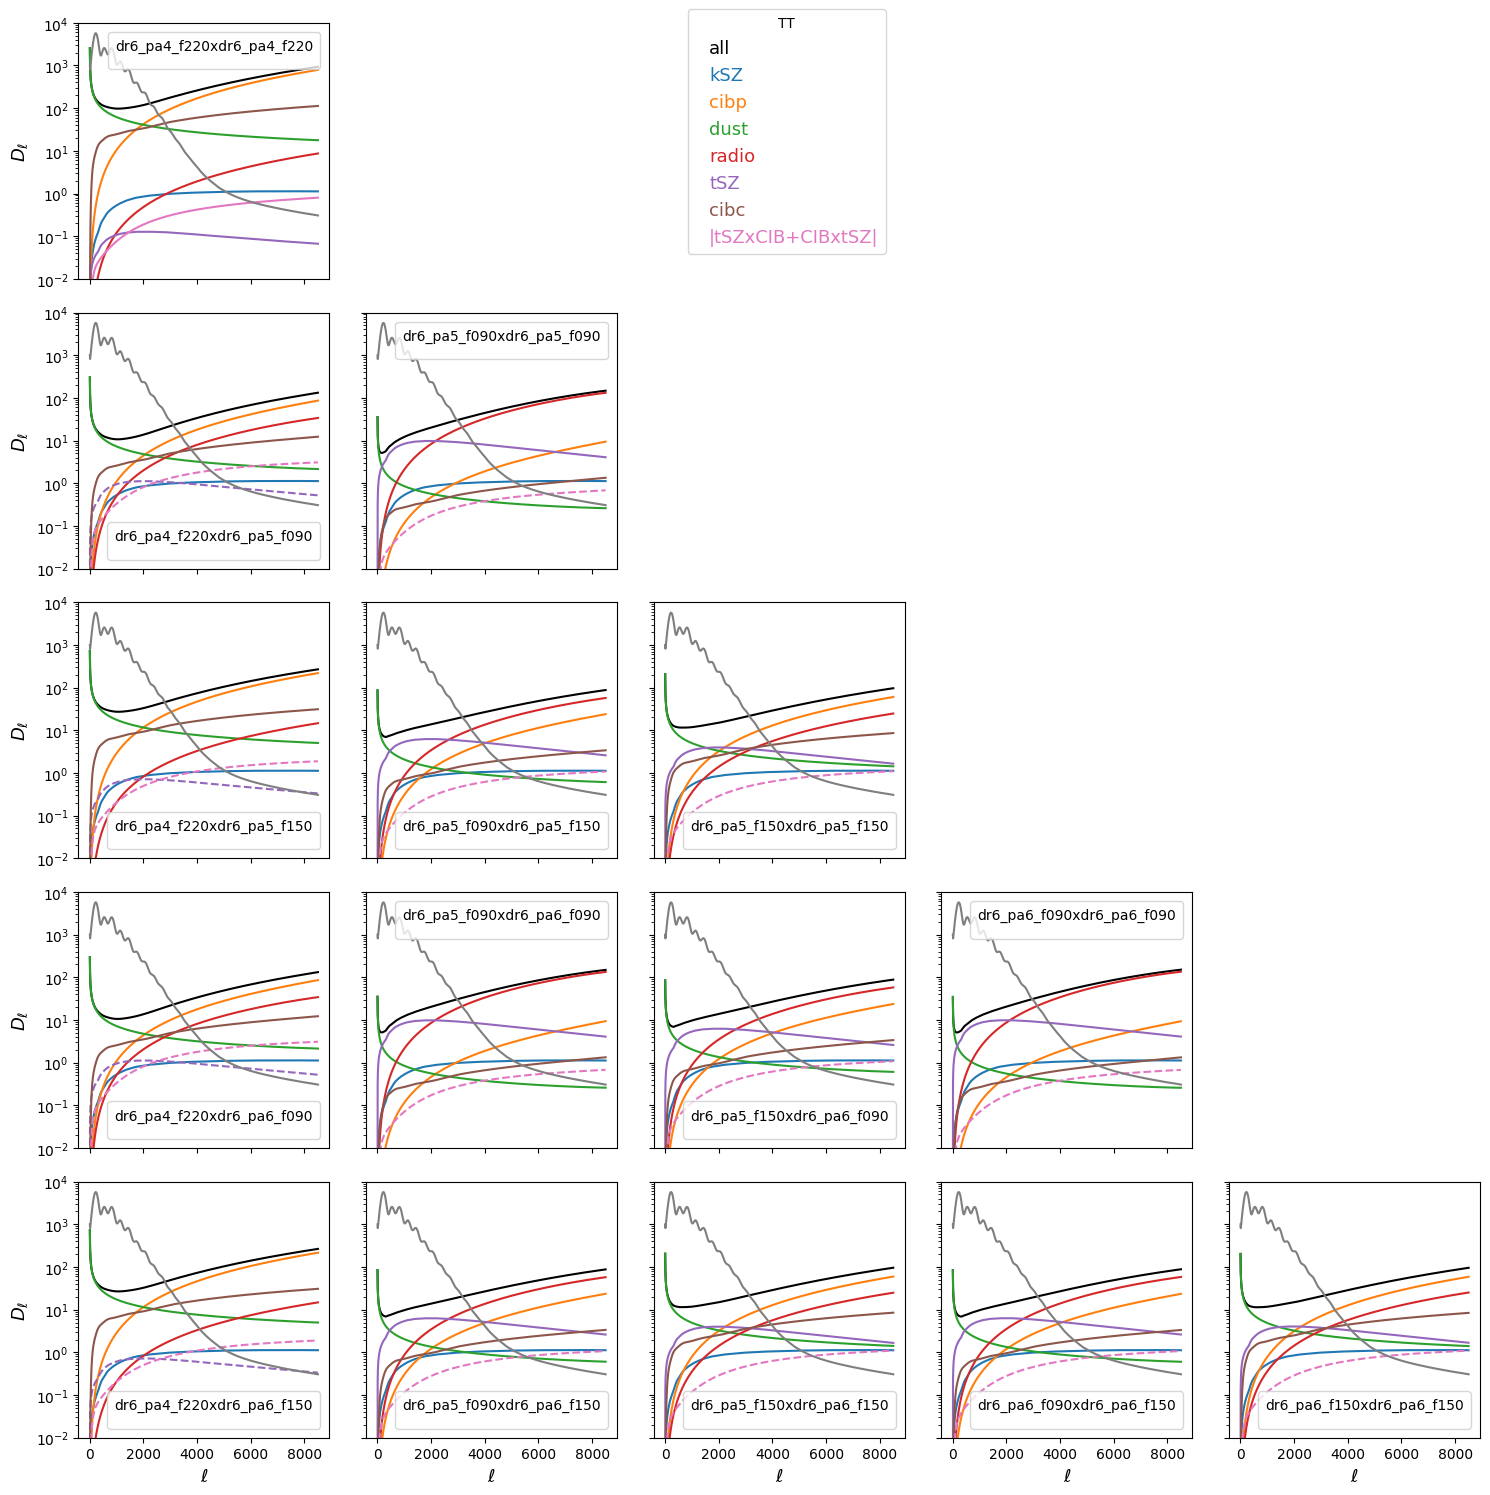

In [ ]:
plot_fg_spectra("tt")

Let's now plot the residuals of our theory model with respect to our data

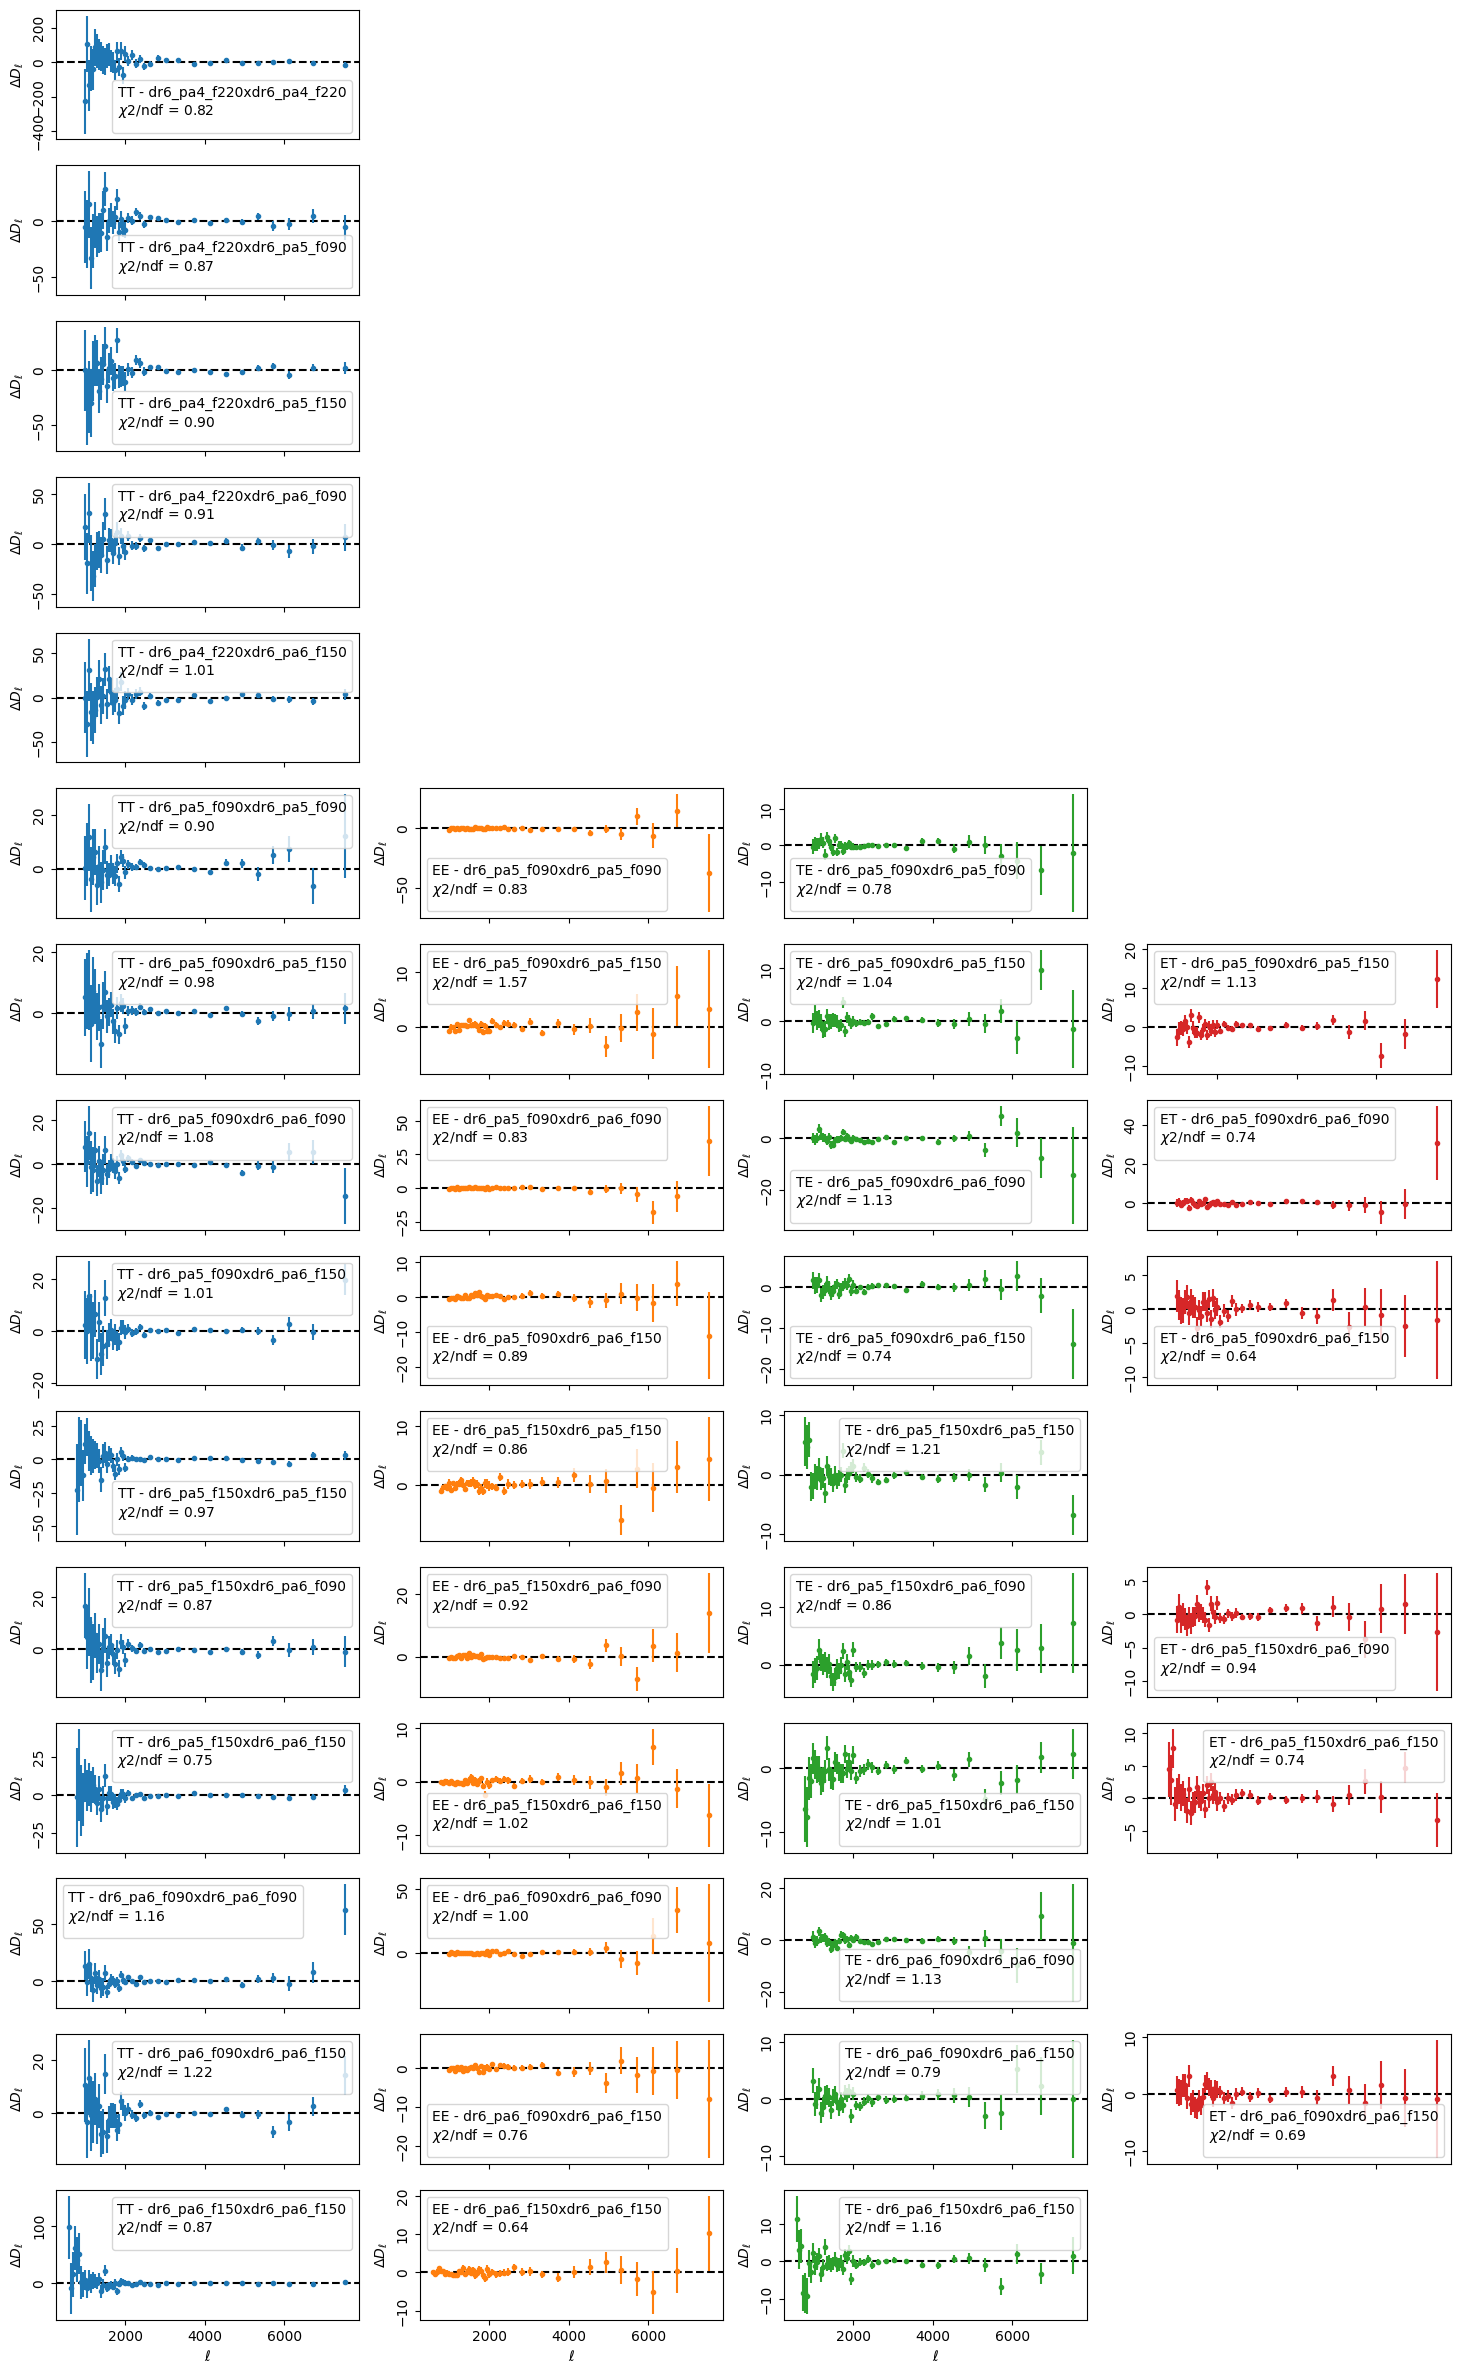

In [ ]:
from itertools import combinations_with_replacement as cwr

modes = ["tt", "ee", "te", "et"]

experiments = act_dr6_like.experiments
crosses = list(cwr(experiments, 2))
fig, axes = plt.subplots(len(crosses), 4, sharex=True, figsize=(18, 2 * len(crosses)))

for data in act_dr6_like.spec_meta:

    # Data/simulation
    lb = data.get("leff")
    db = data.get("cl_data")
    ids = data.get("ids")
    cov = act_dr6_like.cov[np.ix_(ids, ids)]
    db_err = np.sqrt(np.diag(cov))

    # Fit
    cross = (data.get("t1"), data.get("t2"))
    db_fit = dl_obs[data.get("pol"), cross[0], cross[1]] @ data["bpw"].weight
    delta_db = db - db_fit

    irow = crosses.index(cross)
    mode = data.get("pol") if not data.get("hasYX_xsp") else "et"
    icol = modes.index(mode)
    ax = axes[irow, icol]
    ax.axhline(0, color = "k", ls = "--")
    ax.errorbar(lb, delta_db, db_err, fmt=f".C{icol}")

    chi2 = delta_db @ np.linalg.inv(cov) @ delta_db
    title = "{} - {}x{}\n$\chi2$/ndf = {:.2f}".format(mode.upper(), *cross, chi2 / len(delta_db))
    ax.legend([], title=title)


# Remove empty axes
for ax in axes.flatten():
    if not ax.lines:
        fig.delaxes(ax)

for ax in axes[:,:].flatten():
    for tick in ax.get_yticklabels():
        tick.set_rotation(90)
        tick.set_verticalalignment('center')
for ax in axes[:, :].flatten():
    ax.set_ylabel(r"$\Delta D_\ell$")
for ax in axes[-1]:
    ax.set_xlabel(r"$\ell$")

## Use likelihoods to calculate $\chi^2$

We can easily compute the $\chi^2$ from the ACT DR6 likelihood, given the best-fit parameters and our data.
We call the ``act_dr6_like.loglike`` function, which returns the quantity ``logp = -0.5 * chi2 + logp_const``, where ``logp_const`` is just a constant term depending on our data. So, we can derive the $\chi^2$ by computing ``-2*(logp - logp_const)``

In [ ]:
logp = act_dr6_like.loglike(dls, fg_totals, **( fg_params | nuisance_params))

logp_const = act_dr6_like.logp_const
print("chi2 =", -2*(logp - logp_const))

chi2 = 1591.3961598945016


We have also run a minimizer with our likelihood to find the best-fit parameters we have used. We can retrieve the $\chi^2$ found by the minimizer by loading the minimizer chains, and compare it with the one above:

In [ ]:
!wget https://lambda.gsfc.nasa.gov/data/act/chains/lcdm/actbase_lcdm_camb.tar.gz
!tar -xvzf actbase_lcdm_camb.tar.gz

--2025-03-27 15:05:05--  https://lambda.gsfc.nasa.gov/data/act/chains/lcdm/actbase_lcdm_camb.tar.gz
Resolving lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)... 129.164.179.68, 2001:4d0:2310:150::68
Connecting to lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)|129.164.179.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 310599629 (296M) [application/x-gzip]
Saving to: ‘actbase_lcdm_camb.tar.gz.2’

actbase_lcdm_camb.t 100%[===================>] 296.21M  1.73MB/s    in 2m 54s  

2025-03-27 15:08:00 (1.70 MB/s) - ‘actbase_lcdm_camb.tar.gz.2’ saved [310599629/310599629]

actbase_lcdm_camb/
actbase_lcdm_camb/actbase_lcdm_camb.input.yaml.locked
actbase_lcdm_camb/actbase_lcdm_camb.3.txt
actbase_lcdm_camb/actbase_lcdm_camb.minimize.input.yaml
actbase_lcdm_camb/actbase_lcdm_camb.minimize.updated.yaml
actbase_lcdm_camb/actbase_lcdm_camb.progress
actbase_lcdm_camb/actbase_lcdm_camb.input.yaml
actbase_lcdm_camb/actbase_lcdm_camb.updated.yaml
actbase_lcdm_camb/actbase_lcdm_camb.

In [ ]:
from getdist.mcsamples import loadMCSamples
samples = loadMCSamples("actbase_lcdm_camb/actbase_lcdm_camb", settings={'ignore_rows': 0.3})

print(f'R-1 (ACT LCDM): {samples.getGelmanRubin():.3f}')

R-1 (ACT LCDM): 0.003


In [ ]:
bf = samples.getBestFit(max_posterior=True)
for name in bf.names:
    name = name.name
    if "chi2" not in name:
        continue
    if name in ["chi2__CMB"]: continue

    chi2 = bf.parWithName(name).best_fit
    if "DR6MFLike" in name:
        logp_const = act_dr6_like.logp_const
        logp = -0.5 * chi2
        logp_corr = logp - logp_const
        nbins = act_dr6_like.inv_cov.shape[0]
        chi2 = -2 * logp_corr

        print(f"{name}: {chi2} (nbins={nbins})")
    else:
        print(f"{name}: {chi2} ")

chi2__act_dr6_mflike.ACTDR6MFLike: 1590.9132356490136 (nbins=1651)
chi2__planck_2018_lowl.EE_sroll2: 390.0284744 


This value is slightly different from the one above because the minimizer run has been done using the CosmoRec code.

## Running MCMC chains and determining the best-fit cosmology
Here we show the yaml file used with the act_dr6_mflike likelihood to run the ACT-only baseline case. The structure of the yaml is the same of the info dictionary we defined above. You can look at the sub-yamls in each block in the [ACT-DR6-parameters github page](https://github.com/ACTCollaboration/ACT-DR6-parameters/tree/main).



```
debug: false
force: false

output: chains/dr6-camb-lcdm-baseline
sampler:
  mcmc:

theory: !defaults [../theories/camb, ../theories/BandpowerForeground_beams]
likelihood: !defaults [../likelihoods/act_dr6_baseline, ../likelihoods/sroll2]
params: !defaults [../params/cosmology, ../params/foregrounds, ../params/systematics]
prior: !defaults [../priors/foregrounds, ../priors/systematics]
```



To do a minimizer run, we substitute the block
```
sampler:
  mcmc:
```
with
```
sampler:
  minimize:
    method: bobyqa
    ignore_prior: false
    max_evals: 1e6d
    best_of: 16
    covmat: chain_name.covmat
```

## Plotting parameter constraints with `getdist`

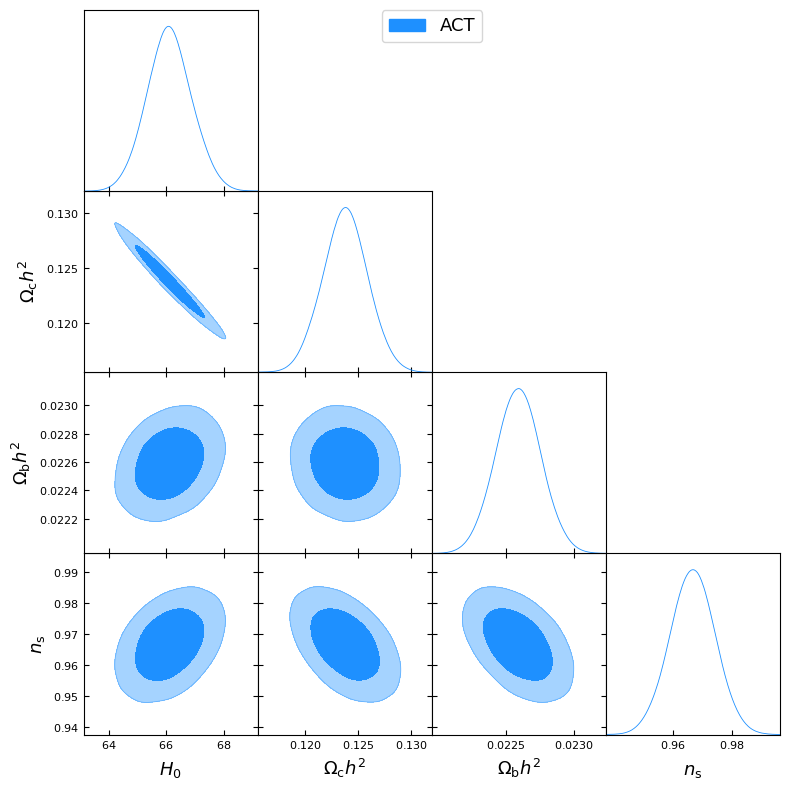

In [ ]:
from getdist import plots

%matplotlib inline

params = ['H0','omch2', 'ombh2', 'ns']

f = plots.getSubplotPlotter(width_inch=8)
f.settings.legend_fontsize = 16
f.settings.axes_labelsize = 16
f.triangle_plot([samples], params, filled=True, legend_labels=['ACT'],
                contour_colors=['DodgerBlue'])

## Model comparison

We can also compare the best-fit (MAP) between different models to estimate an effective $\Delta \chi^2$. Note that since we compute the MAP instead of the MLE, we need to remove contributions from uninformative priors, which can differ beteen the models. In the following, we provide an example calculation of the $\Delta \chi^2$ between the Modified Recombination and $\Lambda$CDM fits to the P-ACT-LB dataset. We also convert this $\Delta \chi^2$ to a significance value.


In [ ]:
!wget https://portal.nersc.gov/project/act/dr6.02/chains/compressed/lcdm/p-actbase-l-b_lcdm_camb.tar.gz
!tar -xvzf p-actbase-l-b_lcdm_camb.tar.gz

!wget https://portal.nersc.gov/project/act/dr6.02/chains/compressed/xe/p-actbase-l-b_xe_class.minimum.txt

--2025-03-20 17:42:24--  https://portal.nersc.gov/project/act/dr6.02/chains/compressed/lcdm/p-actbase-l-b_lcdm_camb.tar.gz
Resolving portal.nersc.gov (portal.nersc.gov)... 128.55.206.112, 128.55.206.107, 128.55.206.106, ...
Connecting to portal.nersc.gov (portal.nersc.gov)|128.55.206.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 163494761 (156M) [application/x-gzip]
Saving to: ‘p-actbase-l-b_lcdm_camb.tar.gz’

p-actbase-l-b_lcdm_ 100%[===================>] 155.92M  24.5MB/s    in 7.3s    

2025-03-20 17:42:32 (21.4 MB/s) - ‘p-actbase-l-b_lcdm_camb.tar.gz’ saved [163494761/163494761]

p-actbase-l-b_lcdm_camb/
p-actbase-l-b_lcdm_camb/p-actbase-l-b_lcdm_camb.minimum.txt
p-actbase-l-b_lcdm_camb/p-actbase-l-b_lcdm_camb.minimize.input.yaml
p-actbase-l-b_lcdm_camb/p-actbase-l-b_lcdm_camb.checkpoint
p-actbase-l-b_lcdm_camb/p-actbase-l-b_lcdm_camb.2.txt
p-actbase-l-b_lcdm_camb/p-actbase-l-b_lcdm_camb.input.yaml
p-actbase-l-b_lcdm_camb/p-actbase-l-b_lcdm_camb.prog

In [ ]:
from scipy import stats


def load_map_values(minimizer_fname):
    """
    Reads the Cobaya minimizer output file and parses it into a dictionary.

    Parameters:
        minimizer_fname (str): Path to the Cobaya minimizer output file. This
                               should end in '.minimum.txt'

    Returns:
        data_dict (dict): A dictionary where the keys are parameter names (from
                          the header row) and the values are the corresponding
                          MAP parameters as floats.
    """

    data_dict = {}

    with open(minimizer_fname, 'r') as file:

        lines = file.readlines()
        header = lines[0].strip().split()[1:]
        values = lines[1].strip().split()

        for key, value in zip(header, values):
            data_dict[key] = float(value)

    return data_dict


def get_chi2_eff(minimizer_fname, log_det=2145.171377675493):
    """
    Computes the effective chi-squared statistic (chi2_eff) from Cobaya
    minimizer output. This effective chi-squared ignores contributions from
    uninformative priors that are defined in the params block of the cobaya yaml.

    Parameters:
        minimizer_fname (str): Path to the Cobaya minimizer output file. This
                               should end in '.minimum.txt'
        log_det (float): Log determinant term in the likelihood. This needs to be subtracted from
                         runs including ACT DR6 MFLike. The default value is the value for DR6 MFLike

    Returns:
        chi2_eff (float): The effective chi-squared value.
    """

    # Load MAP parameters into dictionary
    map_param_dict = load_map_values(minimizer_fname)

    chi2 = map_param_dict['chi2']
    minuslogpost = map_param_dict['minuslogpost']
    minuslogprior = map_param_dict['minuslogprior__0']

    if log_det!=0:
        print(f"Removing log determinant {log_det:.2f}. (Only use this for chains including DR6 MFLike)")
        minuslogpost -= (log_det)
        chi2 -= 2*log_det

    chi2_eff = 2 * (minuslogpost - minuslogprior)


    print(f"chi_sq: {chi2:.3f}")
    print(f"chi_sq_eff: {chi2_eff:.3f}")

    return chi2_eff



chi2_eff_lcdm_pactlb = get_chi2_eff('p-actbase-l-b_lcdm_camb/p-actbase-l-b_lcdm_camb.minimum.txt')
chi2_modrec_pactlb = get_chi2_eff('p-actbase-l-b_xe_class.minimum.txt')
delta_chi2 = chi2_eff_lcdm_pactlb-chi2_modrec_pactlb
n_dof = 7 # ModRec has 7 additional parameters
p_val = stats.chi2.sf(delta_chi2, n_dof)
signif = stats.norm.ppf(1-p_val/2)

print(f"Delta chi^2: {delta_chi2:.3f}")
print(f"p value: {p_val:.4f}")
print(f"Significance: {signif:.4f}")

Removing log determinant 2145.17. (Only use this for chains including DR6 MFLike)
chi_sq: 2267.270
chi_sq_eff: 2216.714
Removing log determinant 2145.17. (Only use this for chains including DR6 MFLike)
chi_sq: 2257.412
chi_sq_eff: 2205.157
Delta chi^2: 11.557
p value: 0.1161
Significance: 1.5714


## High-accuracy CLASS settings
For reference, we also list the high-accuracy CLASS settings here.

In [ ]:
cosmo_settings = {
                    'N_ncdm': 1,
                    'm_ncdm': 0.06,
                    'N_ur': 2.0308,
                    'T_cmb': 2.7255,
                    'YHe': 'BBN',
                    'non linear':'hmcode',
                    'hmcode_version': '2020',
                    'recombination': 'HyRec',
                    'lensing':'yes',
                    'output': 'tCl, pCl, lCl, mPk',
                    'modes': 's',
                    'l_max_scalars': 9500,
                    'delta_l_max': 1800,
                    'P_k_max_h/Mpc': 100.0,
                    'l_logstep': 1.025,
                    'l_linstep': 20,
                    'perturbations_sampling_stepsize': 0.05,
                    'l_switch_limber': 30.0,
                    'hyper_sampling_flat': 32.0,
                    'l_max_g': 40,
                    'l_max_ur': 35,
                    'l_max_pol_g': 60,
                    'ur_fluid_approximation': 2,
                    'ur_fluid_trigger_tau_over_tau_k': 130.0,
                    'radiation_streaming_approximation': 2,
                    'radiation_streaming_trigger_tau_over_tau_k': 240.0,
                    'hyper_flat_approximation_nu': 7000.0,
                    'transfer_neglect_delta_k_S_t0': 0.17,
                    'transfer_neglect_delta_k_S_t1': 0.05,
                    'transfer_neglect_delta_k_S_t2': 0.17,
                    'transfer_neglect_delta_k_S_e': 0.17,
                    'accurate_lensing': 1,
                    'start_small_k_at_tau_c_over_tau_h': 0.0004,
                    'start_large_k_at_tau_h_over_tau_k': 0.05,
                    'tight_coupling_trigger_tau_c_over_tau_h': 0.005,
                    'tight_coupling_trigger_tau_c_over_tau_k': 0.008,
                    'start_sources_at_tau_c_over_tau_h': 0.006,
                    'l_max_ncdm': 30,
                    'tol_ncdm_synchronous': 1.0e-06
                    }

# CMB-only likelihood

We also provide `ACT-lite`, a compressed likelihood for data where we have pre-marginalized over foregrounds and most instrumental nuisance parameters. This likelihood is more compact, and targets cosmological inference when information about the astrophyiscal foregrounds or instrumental properties are less important.

Here, we show how we install this likelihood, what settings can be used with it, and some key differences from the MFLike likelihood.

# Downloading ACT-lite

In [ ]:
!git clone https://github.com/ACTCollaboration/DR6-ACT-lite.git
!cd DR6-ACT-lite; pip install -e .

In [ ]:
import sys
sys.path.append('./DR6-ACT-lite')

# Example yaml files

The `ACT-lite` likelihood comes with several pre-made configuration files in the `yamls/` sub-directory. We can run chains from these with cobaya through the command line. For example, we can run an ACT-only constraint by running the file `act-lcdm.yaml`. Let's take a look at what that file is structured like.

In [ ]:
!cat DR6-ACT-lite/yamls/act-lcdm.yaml

# The Likelihood itself

Below we show the input files for the likelihood itself. Note that it is a lot more compact than the multifrequency likelihood. From top-to-bottom, all that this likelihood specifies is:

* `input_file`: the data file it loaded,
* `ell_cuts`: which ell-cuts to use. By default, the likelihood uses the full range from 600 to 6500 (the upper limit of 8500 is more generous than the data that is actually contained within the file).
* `params`: there are only two parameters in the entire likelihood, the global gain calibration `A_act` and the polarization efficiency `P_act`. Both of these are simply multiplicative factors to the power spectra. We normally measure the former through a prior (`A_act = 1.0 +/- 0.003`) that comes from the Planck dipole measurement (you can see this prior defined in the configuation file above in the `cal_dip_prior` definition).

In [ ]:
!cat DR6-ACT-lite/yamls/likelihoods/act_lite.yaml

# Combining with Planck

We also provide a simple likelihood to combine ACT with Planck for our P-ACT combination. This likelihood simply loads the `plik-lite` data and imposes a hard cut at ell = 1000/600/600 in TT/TE/EE.

The only remaining nuance when combining with Planck is that both ACT and Planck calibrate their gain to the Planck dipole measurement. As a result, we need to fix their two calibration parameters to each other, settings `A_act = A_planck`.

In [ ]:
!cat DR6-ACT-lite/yamls/likelihoods/p_act_lite.yaml

# Inference with ACT-lite

We can load one of these yaml files and run a chain with it. Below here we do this through cobaya's python interface. You can alternatively run this directly in the command line through the command:

```
  cobaya-run DR6-ACT-lite/yamls/act-lcdm.yaml
```

In [ ]:
from cobaya.yaml import yaml_load_file

# Load the configuration file into python.
info = yaml_load_file("DR6-ACT-lite/yamls/act-lcdm.yaml")
info["packages_path"] = "./packages"
info["theory"]["camb"]["extra_args"]["recombination_model"] = "Recfast"

# For time constraints, let's set a limit on how many samples we will actually take.
# If you want to run a full chain, comment out this line.
info["sampler"]["mcmc"]["max_samples"] = 1000

# See the full output below:
info

In [ ]:
from cobaya.install import install

# Install the data.
packages_path = "./packages"
install(info, path=packages_path, no_set_global=True, skip_global=True, debug= True);

In [ ]:
from cobaya.model import get_model
from cobaya.output import get_output
from cobaya.sampler import get_sampler

out = get_output(prefix="chains/example", resume=False, force=True)
# Compile the info into a model.
model = get_model(info)

# Run only a short amount of samples for now (1000 in this case).
info_sampler = { "mcmc" : { "max_samples": 1000 } }
mcmc = get_sampler(info_sampler, model=model, output=out)
mcmc.run()

INFO:output:Output to be read-from/written-into folder 'chains', with prefix 'example'


 2025-03-27 11:19:09,719 [output] Output to be read-from/written-into folder 'chains', with prefix 'example'


INFO:output:Found existing info files with the requested output prefix: 'chains/example'


 2025-03-27 11:19:09,724 [output] Found existing info files with the requested output prefix: 'chains/example'


INFO:output:Will delete previous products ('force' was requested).


...

 2025-03-27 11:40:05,438 [mcmc] Progress @ 2025-03-27 11:40:05 : 776 steps taken, and 49 accepted.


INFO:mcmc:Reached maximum number of accepted steps allowed (50). Stopping.


 2025-03-27 11:40:25,949 [mcmc] Reached maximum number of accepted steps allowed (50). Stopping.


INFO:mcmc:Sampling complete after 50 accepted steps.


 2025-03-27 11:40:25,954 [mcmc] Sampling complete after 50 accepted steps.
